# Price-Aware Transformer

This notebook implements a custom Transformer for financial time series prediction.

Unlike the previous notebook, attention is modified using market-aware biases instead of relying only on dot-product similarity.

Goal:
- Build a finance-specific Transformer
- Compare against standard Transformer
- Evaluate whether market-aware attention improves prediction and trading performance

In [1]:
import math
import time
import pickle

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [ ]:
baseline_results = pd.read_csv("experiments/baseline_results.csv")
trading_results = pd.read_csv("experiments/trading_results.csv")
experiment_log = pd.read_csv("experiments/experiment_log.csv")

In [2]:
X_train = torch.tensor(np.load("pipeline/X_train.npy"), dtype=torch.float32)
y_train = torch.tensor(np.load("pipeline/y_train.npy"), dtype=torch.float32)

X_val = torch.tensor(np.load("pipeline/X_val.npy"), dtype=torch.float32)
y_val = torch.tensor(np.load("pipeline/y_val.npy"), dtype=torch.float32)

X_test = torch.tensor(np.load("pipeline/X_test.npy"), dtype=torch.float32)
y_test = torch.tensor(np.load("pipeline/y_test.npy"), dtype=torch.float32)

In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([1844, 60, 95])
torch.Size([1844])
torch.Size([348, 60, 95])
torch.Size([348])
torch.Size([349, 60, 95])
torch.Size([349])


In [4]:
INPUT_DIM = X_train.shape[2]
SEQ_LENGTH = X_train.shape[1]
D_MODEL = 128
NUM_HEADS = 8
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 5

In [5]:
X_train = X_train.to(DEVICE)
y_train = y_train.to(DEVICE)

X_val = X_val.to(DEVICE)
y_val = y_val.to(DEVICE)

X_test = X_test.to(DEVICE)
y_test = y_test.to(DEVICE)

In [6]:
print(X_train.device)

cuda:0


## Positional Encoding

Transformers have no inherent understanding of sequence order.

Positional Encoding injects temporal information into every token before self-attention.

In [7]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )
        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:,:x.size(1)]

In [8]:
sample = PositionalEncoding(D_MODEL)
print(sample.pe.shape)

torch.Size([1, 5000, 128])


## Feed Forward Network

Each encoder block applies a two-layer MLP after self-attention to increase model capacity.

In [9]:
class FeedForward(nn.Module):

    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
    def forward(self, x):
        return self.net(x)

In [10]:
ff = FeedForward(D_MODEL, FF_DIM, DROPOUT)

dummy = torch.randn(32,60,D_MODEL)

print(ff(dummy).shape)

torch.Size([32, 60, 128])


# Price-Aware Attention

Standard Transformer computes attention solely from feature similarity:

Attention(Q,K,V)=Softmax(QKᵀ/√d)V

Financial markets also exhibit structural relationships.

Two time steps with similar prices should naturally receive greater attention than two time steps with very different prices.

To incorporate this prior knowledge, we modify the attention score:

Score = QKᵀ/√d + λM

where M is a market-aware bias matrix computed from price similarity.

This is the core contribution of the custom Transformer.

## Price-Aware Scaled Dot Product Attention

Standard attention measures similarity using only the learned Query and Key vectors.

Here we introduce a market-aware bias based on the similarity of historical prices.

Timesteps with similar prices receive a positive bias, while distant prices are penalized.

This bias is added before the Softmax operation, allowing the model to learn from both feature similarity and market structure.

In [211]:
class PriceAwareAttention(nn.Module):
    def __init__(self, d_k, alpha=0.1):
        super().__init__()
        self.scale = math.sqrt(d_k)
        self.alpha = alpha

    def forward(self, Q, K, V, prices):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        price_diff = torch.abs(prices.unsqueeze(-1) - prices.unsqueeze(-2))
        price_bias = -price_diff

        scores = scores + self.alpha * price_bias.unsqueeze(1)

        weights = F.softmax(scores, dim=-1)

        output = torch.matmul(weights, V)

        return output, weights

In [212]:
attention = PriceAwareAttention(d_k=64)

Q = torch.randn(2,8,60,64)
K = torch.randn(2,8,60,64)
V = torch.randn(2,8,60,64)

prices = torch.randn(2,60)

output, weights = attention(Q, K, V, prices)

print(output.shape)
print(weights.shape)

torch.Size([2, 8, 60, 64])
torch.Size([2, 8, 60, 60])


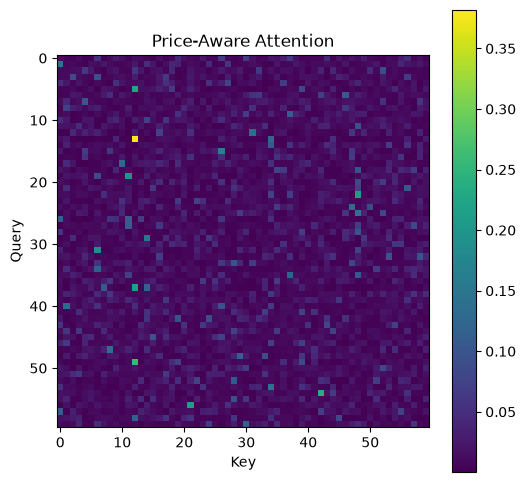

In [213]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0,0].detach().cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Price-Aware Attention")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

## Price-Aware Multi-Head Attention

The previous module implemented a single attention head.

This module projects the input into multiple subspaces, applies Price-Aware Attention independently to each head, concatenates the outputs, and projects them back to the model dimension.

This allows the model to simultaneously learn different financial relationships.

In [214]:
class PriceAwareMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, alpha=0.1):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        self.attention = PriceAwareAttention(self.d_k, alpha)

        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, prices):
        B, T, _ = x.shape

        Q = self.q_proj(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.k_proj(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.v_proj(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)

        output, weights = self.attention(Q, K, V, prices)

        output = output.transpose(1,2).contiguous().view(B, T, self.d_model)
        output = self.out_proj(output)

        return output, weights

In [215]:
mha = PriceAwareMultiHeadAttention(D_MODEL, NUM_HEADS)

dummy = torch.randn(16, SEQ_LENGTH, D_MODEL)
prices = torch.randn(16, SEQ_LENGTH)

output, weights = mha(dummy, prices)

print(output.shape)
print(weights.shape)

torch.Size([16, 60, 128])
torch.Size([16, 8, 60, 60])


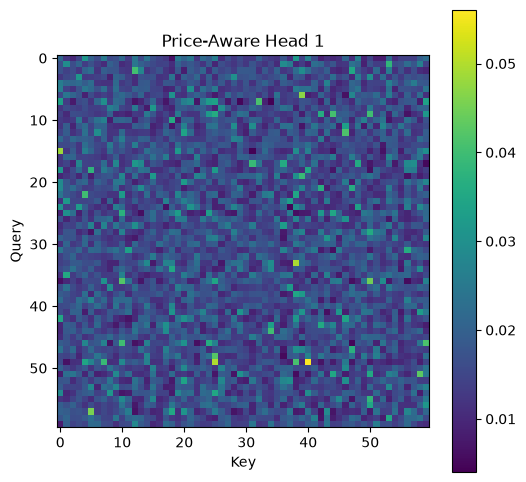

In [216]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0,0].detach().cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Price-Aware Head 1")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

## Price-Aware Encoder Layer

Each encoder layer consists of:

1. Price-Aware Multi-Head Attention
2. Residual Connection
3. Layer Normalization
4. Feed Forward Network
5. Residual Connection
6. Layer Normalization

Multiple encoder layers will later be stacked to build the complete Transformer.

In [217]:
class PriceAwareEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, alpha=0.1):
        super().__init__()

        self.attention = PriceAwareMultiHeadAttention(d_model, num_heads, alpha)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = FeedForward(d_model, ff_dim, dropout)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, prices):
        attn_out, weights = self.attention(x, prices)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x, weights

In [218]:
layer = PriceAwareEncoderLayer(D_MODEL, NUM_HEADS, FF_DIM)

dummy = torch.randn(8, SEQ_LENGTH, D_MODEL)
prices = torch.randn(8, SEQ_LENGTH)

output, weights = layer(dummy, prices)

print(output.shape)
print(weights.shape)

torch.Size([8, 60, 128])
torch.Size([8, 8, 60, 60])


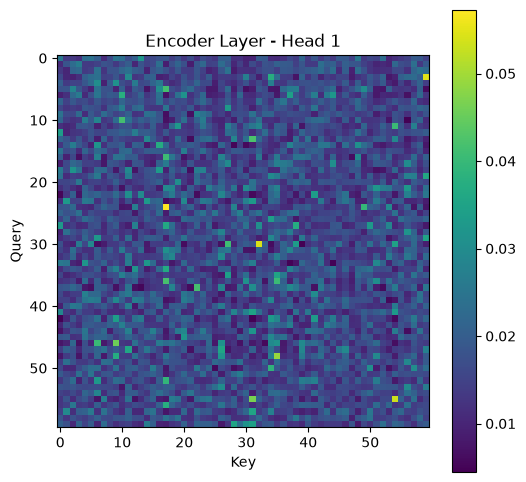

In [219]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0,0].detach().cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Encoder Layer - Head 1")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

## Custom Transformer

The complete model consists of:

- Input Projection
- Positional Encoding
- Stacked Price-Aware Encoder Layers
- Global Average Pooling
- Regression Head

The encoder stack extracts temporal representations, while the regression head predicts the next normalized closing price.

In [220]:
class CustomTransformer(nn.Module):
    def __init__(self, input_dim, d_model, num_heads, ff_dim, num_layers, dropout=0.1, alpha=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional = PositionalEncoding(d_model)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            PriceAwareEncoderLayer(d_model, num_heads, ff_dim, dropout, alpha)
            for _ in range(num_layers)
        ])

        self.regressor = nn.Linear(d_model, 1)

    def forward(self, x):
        prices = x[:,:,0]

        x = self.input_proj(x)
        x = self.positional(x)
        x = self.dropout(x)

        attention_maps = []

        for layer in self.layers:
            x, weights = layer(x, prices)
            attention_maps.append(weights)

        x = x.mean(dim=1)
        prediction = self.regressor(x).squeeze(-1)

        return prediction, attention_maps

In [221]:
model = CustomTransformer(
    INPUT_DIM,
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    DROPOUT
).to(DEVICE)

model

CustomTransformer(
  (input_proj): Linear(in_features=95, out_features=128, bias=True)
  (positional): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x PriceAwareEncoderLayer(
      (attention): PriceAwareMultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): PriceAwareAttention()
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (norm2): LayerNor

In [222]:
dummy = torch.randn(16, SEQ_LENGTH, INPUT_DIM).to(DEVICE)

pred, attention = model(dummy)

print(pred.shape)
print(len(attention))
print(attention[0].shape)

torch.Size([16])
2
torch.Size([16, 8, 60, 60])


In [223]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters : {total:,}")
print(f"Trainable : {trainable:,}")

Total Parameters : 277,377
Trainable : 277,377


## Model Training

The model is trained using Mean Squared Error loss and the Adam optimizer.

Early stopping monitors validation loss and prevents overfitting by restoring the best-performing model.

In [224]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8
)

In [225]:
best_loss = float("inf")
best_epoch = 0
patience_counter = 0

train_losses = []
val_losses = []

start_time = time.time()

## Training Loop

For each epoch:

1. Train on the training set
2. Evaluate on the validation set
3. Update the learning rate scheduler
4. Save the best model
5. Apply early stopping

In [226]:
scaler = torch.amp.GradScaler("cuda")

In [227]:
for epoch in range(EPOCHS):

    model.train()
    optimizer.zero_grad()

    with torch.amp.autocast("cuda"):
        pred, _ = model(X_train)
        train_loss = criterion(pred, y_train)

    scaler.scale(train_loss).backward()
    scaler.step(optimizer)
    scaler.update()

    model.eval()

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            val_pred, _ = model(X_val)
            val_loss = criterion(val_pred, y_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

    if val_loss < best_loss:
        best_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), "models/custom_transformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

Epoch 01/15 | Train 0.138832 | Val 0.208266
Epoch 02/15 | Train 1.415316 | Val 0.208266
Epoch 03/15 | Train 1.412810 | Val 0.208266
Epoch 04/15 | Train 1.412424 | Val 0.179837
Epoch 05/15 | Train 0.183325 | Val 0.033231
Epoch 06/15 | Train 0.160498 | Val 0.057871
Epoch 07/15 | Train 0.454131 | Val 0.228749
Epoch 08/15 | Train 0.373988 | Val 0.291775
Epoch 09/15 | Train 0.170659 | Val 0.198053
Epoch 10/15 | Train 0.052821 | Val 0.055863
Early stopping


In [228]:
train_time = time.time() - start_time

print(f"Training Time : {train_time:.2f} sec")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Loss : {best_loss:.6f}")

Training Time : 2.02 sec
Best Epoch : 5
Best Validation Loss : 0.033231


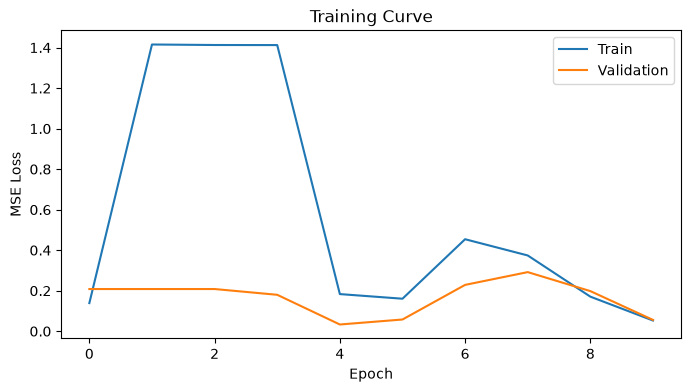

In [229]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

In [230]:
with torch.no_grad():
    pred, attention = model(X_test)

pred = pred.cpu().numpy()
true = y_test.cpu().numpy()

In [231]:
mae = mean_absolute_error(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))
r2 = r2_score(true, pred)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.280036
RMSE: 0.284159
R²  : -44.416771


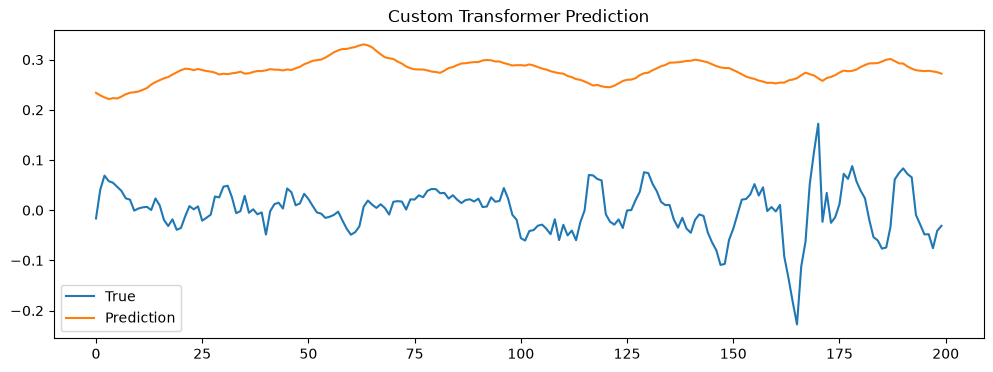

In [232]:
plt.figure(figsize=(12,4))
plt.plot(true[:200], label="True")
plt.plot(pred[:200], label="Prediction")
plt.title("Custom Transformer Prediction")
plt.legend()
plt.show()

In [233]:
from pipeline.metrics import evaluate_trading_metrics

metrics = evaluate_trading_metrics(true, pred)

metrics

{'Directional Accuracy': np.float64(0.5644699140401146),
 'Hit Rate': np.float64(0.5644699140401146),
 'Sharpe': np.float64(1.7527435211050182),
 'Strategy Return': np.float32(2.6947522),
 'Max Drawdown': np.float32(-0.7979198)}

In [234]:
results = pd.read_csv("experiments/experiment_log.csv")

results.loc[len(results)] = {
    "Experiment":"Custom Transformer",
    "Model":"Custom Transformer",
    "Parameters":sum(p.numel() for p in model.parameters()),
    "Train Time (s)":train_time,
    "Epochs":best_epoch,
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":metrics["Directional Accuracy"],
    "Hit Rate":metrics["Hit Rate"],
    "Sharpe":metrics["Sharpe"],
    "Strategy Return":metrics["Strategy Return"],
    "Max Drawdown":metrics["Max Drawdown"],
    "Notes":"Price-Aware Attention"
}

results.to_csv("experiments/experiment_log.csv", index=False)

results

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
0,Baseline,Linear Regression,NaN,NaN,NaN,0.188742,0.248706,-33.790931,0.467049,0.467049,-0.398144,-0.494425,-0.694398,Baseline
1,Baseline,Random Forest,NaN,NaN,NaN,0.033050,0.045135,-0.145847,0.515759,0.515759,0.334000,0.001970,-0.675468,Baseline
2,Baseline,LSTM,NaN,NaN,NaN,0.040036,0.052256,-0.535912,0.489971,0.489971,-0.132552,-0.350803,-0.741019,Baseline
3,Baseline,GRU,NaN,NaN,NaN,0.034453,0.047614,-0.275127,0.478510,0.478510,-0.142696,-0.357364,-0.782726,Baseline
4,Baseline,XGBoost,NaN,NaN,NaN,0.034423,0.045011,-0.139553,0.578797,0.578797,2.789059,8.535793,-0.703745,Baseline
5,Baseline,PyTorch Transformer,813697.0,10.260000,15.0,0.032234,0.043543,-0.066416,0.441261,0.441261,-0.799614,-0.651581,-0.850522,nn.TransformerEncoder
6,Custom Transformer,Custom Transformer,277377.0,4.133688,15.0,0.030962,0.043111,-0.045353,0.521490,0.521490,0.177760,-0.139390,-0.601280,Built completely from scratch
7,Custom Transformer,Custom Transformer,277377.0,3.748291,4.0,0.148615,0.155509,-12.601940,0.435530,0.435530,-1.752744,-0.856143,-0.910708,Price-Aware Attention
8,Custom Transformer,Custom Transformer,277377.0,6.047931,8.0,0.087510,0.097774,-4.377023,0.564470,0.564470,1.752744,2.694752,-0.797920,Price-Aware Attention
9,Custom Transformer,Custom Transformer,277377.0,3.780146,5.0,0.468152,0.470935,-123.742447,0.435530,0.435530,-1.752744,-0.856143,-0.910708,Price-Aware Attention


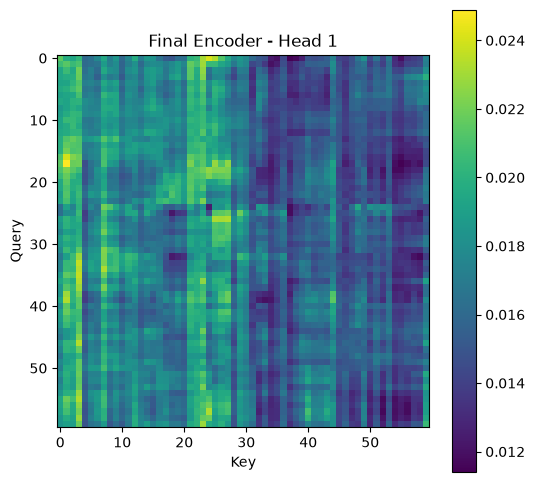

In [235]:
sample = X_test[:1]

with torch.no_grad():
    _, attention = model(sample)

attn = attention[-1][0,0].cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(attn, cmap="viridis")
plt.colorbar()
plt.title("Final Encoder - Head 1")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

In [236]:
results = pd.read_csv("experiments/experiment_log.csv")
results

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
0,Baseline,Linear Regression,NaN,NaN,NaN,0.188742,0.248706,-33.790931,0.467049,0.467049,-0.398144,-0.494425,-0.694398,Baseline
1,Baseline,Random Forest,NaN,NaN,NaN,0.033050,0.045135,-0.145847,0.515759,0.515759,0.334000,0.001970,-0.675468,Baseline
2,Baseline,LSTM,NaN,NaN,NaN,0.040036,0.052256,-0.535912,0.489971,0.489971,-0.132552,-0.350803,-0.741019,Baseline
3,Baseline,GRU,NaN,NaN,NaN,0.034453,0.047614,-0.275127,0.478510,0.478510,-0.142696,-0.357364,-0.782726,Baseline
4,Baseline,XGBoost,NaN,NaN,NaN,0.034423,0.045011,-0.139553,0.578797,0.578797,2.789059,8.535793,-0.703745,Baseline
5,Baseline,PyTorch Transformer,813697.0,10.260000,15.0,0.032234,0.043543,-0.066416,0.441261,0.441261,-0.799614,-0.651581,-0.850522,nn.TransformerEncoder
6,Custom Transformer,Custom Transformer,277377.0,4.133688,15.0,0.030962,0.043111,-0.045353,0.521490,0.521490,0.177760,-0.139390,-0.601280,Built completely from scratch
7,Custom Transformer,Custom Transformer,277377.0,3.748291,4.0,0.148615,0.155509,-12.601940,0.435530,0.435530,-1.752744,-0.856143,-0.910708,Price-Aware Attention
8,Custom Transformer,Custom Transformer,277377.0,6.047931,8.0,0.087510,0.097774,-4.377023,0.564470,0.564470,1.752744,2.694752,-0.797920,Price-Aware Attention
9,Custom Transformer,Custom Transformer,277377.0,3.780146,5.0,0.468152,0.470935,-123.742447,0.435530,0.435530,-1.752744,-0.856143,-0.910708,Price-Aware Attention


In [242]:
baseline = pd.read_csv("experiments/baseline_results.csv")

baseline.loc[len(baseline)] = [
    "Price Aware Transformer",
    mae,
    rmse,
    r2
]

baseline.to_csv("experiments/baseline_results.csv", index=False)

baseline

,Model,MAE,RMSE,R2
0,Linear Regression,0.188742,0.248706,-33.790931
1,Random Forest,0.033050,0.045135,-0.145847
2,LSTM,0.040036,0.052256,-0.535912
3,GRU,0.034453,0.047614,-0.275127
4,XGBoost,0.034423,0.045011,-0.139553
5,PyTorch Transformer,0.032234,0.043543,-0.066416
6,Custom Transformer,0.030962,0.043111,-0.045353
7,Price Aware Transformer,0.280036,0.284159,-44.416771


In [243]:
trading = pd.read_csv("experiments/trading_results.csv")

trading.loc[len(trading)] = [
    "Price-Aware Transformer",
    metrics["Directional Accuracy"],
    metrics["Hit Rate"],
    metrics["Sharpe"],
    metrics["Strategy Return"],
    metrics["Max Drawdown"]
]

trading.to_csv("experiments/trading_results.csv", index=False)

trading

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
7,Price-Aware Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920


In [244]:
baseline = pd.read_csv("experiments/baseline_results.csv")
trading = pd.read_csv("experiments/trading_results.csv")

display(baseline.sort_values("MAE"))
display(trading.sort_values("Sharpe", ascending=False))

,Model,MAE,RMSE,R2
6,Custom Transformer,0.030962,0.043111,-0.045353
5,PyTorch Transformer,0.032234,0.043543,-0.066416
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
0,Linear Regression,0.188742,0.248706,-33.790931
7,Price Aware Transformer,0.280036,0.284159,-44.416771


,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
7,Price-Aware Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522
